In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score, 
    roc_curve, 
    auc, 
    roc_auc_score
)

In [2]:
df= pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
df.isna().sum().sum()

np.int64(0)

In [7]:
df.duplicated().any()     # Returns True → duplicates exist     Returns False → no duplicates

np.True_

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


#### Dropping the 1 Duplicate Entry

In [10]:
df=df.drop_duplicates()

In [11]:
df.dtypes


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [13]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [14]:
# Getting the value count of each column using value_counts

for col in df.columns:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("-"*70)

Value counts for age:
age
58    19
57    17
54    16
59    14
52    13
51    12
62    11
44    11
56    11
60    11
64    10
41    10
63     9
67     9
65     8
53     8
61     8
45     8
43     8
42     8
55     8
66     7
48     7
50     7
46     7
49     5
47     5
68     4
39     4
35     4
70     4
40     3
69     3
71     3
37     2
38     2
34     2
29     1
74     1
76     1
77     1
Name: count, dtype: int64
----------------------------------------------------------------------
Value counts for sex:
sex
1    206
0     96
Name: count, dtype: int64
----------------------------------------------------------------------
Value counts for cp:
cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64
----------------------------------------------------------------------
Value counts for trestbps:
trestbps
120    37
130    36
140    32
110    19
150    17
138    12
128    12
125    11
160    11
112     9
132     8
118     7
108     6
124     6
135     6
145     5
152     5
134 

In [15]:
#Checking skewness and kutosis 
num_cols = df.select_dtypes(include='number').columns
print("Skewness:\n", df[num_cols].skew())
print("\nKurtosis:\n", df[num_cols].kurt())

Skewness:
 age        -0.203743
sex        -0.786120
cp          0.493022
trestbps    0.716541
chol        1.147332
fbs         1.981201
restecg     0.169467
thalach    -0.532671
exang       0.737281
oldpeak     1.266173
slope      -0.503247
ca          1.295738
thal       -0.481232
target     -0.173691
dtype: float64

Kurtosis:
 age        -0.527512
sex        -1.391273
cp         -1.183729
trestbps    0.922996
chol        4.542591
fbs         1.937947
restecg    -1.359464
thalach    -0.062186
exang      -1.466170
oldpeak     1.567876
slope      -0.629935
ca          0.781003
thal        0.295855
target     -1.983008
dtype: float64


In [16]:
# Capping: Cap the values at the 1st and 99th percentile. This keeps the data point but prevents it from being a "wild" outlier.abs

upper_limit = df['chol'].quantile(0.99)
df['chol'] = np.where(df['chol'] > upper_limit, upper_limit, df['chol'])

In [17]:
#log transformation to reduce skewness of old peak
df['oldpeak_log'] = np.log1p(df['oldpeak'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          302 non-null    int64  
 1   sex          302 non-null    int64  
 2   cp           302 non-null    int64  
 3   trestbps     302 non-null    int64  
 4   chol         302 non-null    float64
 5   fbs          302 non-null    int64  
 6   restecg      302 non-null    int64  
 7   thalach      302 non-null    int64  
 8   exang        302 non-null    int64  
 9   oldpeak      302 non-null    float64
 10  slope        302 non-null    int64  
 11  ca           302 non-null    int64  
 12  thal         302 non-null    int64  
 13  target       302 non-null    int64  
 14  oldpeak_log  302 non-null    float64
dtypes: float64(3), int64(12)
memory usage: 37.8 KB


In [19]:
print("Skewness: ",df['oldpeak_log'].skew())
print("kurtosis: ",df['oldpeak_log'].kurt())

Skewness:  0.39194640304330175
kurtosis:  -1.038745743192159


<Axes: title={'center': 'Count Plot of the Target'}, xlabel='Target', ylabel='Count'>

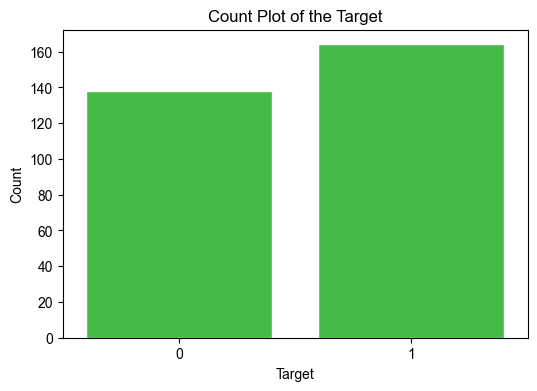

In [20]:
plt.figure(figsize=(6,4))
plt.title("Count Plot of the Target")
plt.xlabel('Target')
plt.ylabel('Count')
sns.set_style('whitegrid')
sns.countplot(x='target', data=df,color="limegreen")

### Plotting histograms for age, trestbps, chol, and thalach

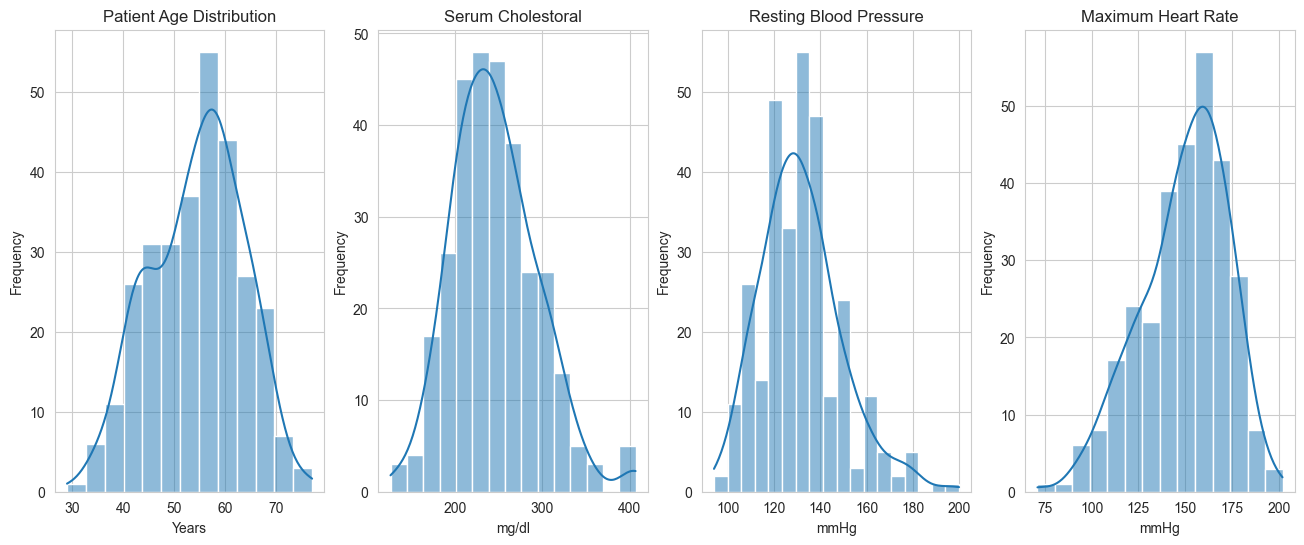

In [21]:
plot_meta = {
    'age': {'title': 'Patient Age Distribution', 'xlabel': 'Years','ylabel' : 'Frequency'},
    'chol': {'title': 'Serum Cholestoral', 'xlabel': 'mg/dl','ylabel' : 'Frequency'},
    'trestbps': {'title': 'Resting Blood Pressure', 'xlabel': 'mmHg','ylabel' : 'Frequency'},
    'thalach': {'title': 'Maximum Heart Rate', 'xlabel': 'mmHg','ylabel' : 'Frequency'}
}

plt.figure(figsize=(16, 6))

for i, (col, meta) in enumerate(plot_meta.items()):
    plt.subplot(1, 4, i+1)
    sns.histplot(df[col], fill=True,kde = True)
    plt.title(meta['title'])
    plt.xlabel(meta['xlabel'])
    plt.ylabel(meta['ylabel'])

plt.show()

### Bar charts for categorical features such as sex, cp (chest pain type), fbs (fasting blood sugar), and restecg.

In [22]:
# Made copy of dataset so that we can map the categorical column values to original values so that the plots can be even cleaner
temp_df = df.copy()
temp_df['sex'] = temp_df['sex'].map({0:'Female',1:'Male'})
temp_df['cp'] = temp_df['cp'].map({0: 'Typical', 1: 'Atypical', 2: 'Non-anginal', 3: 'Asymptomatic'})
temp_df['fbs'] = temp_df['fbs'].map({0:'No',1:'Yes'})
temp_df['restecg'] = temp_df['restecg'].map({0: 'Normal',1: 'ST-T wave abnormality',2: 'Left ventricular hypertrophy'})

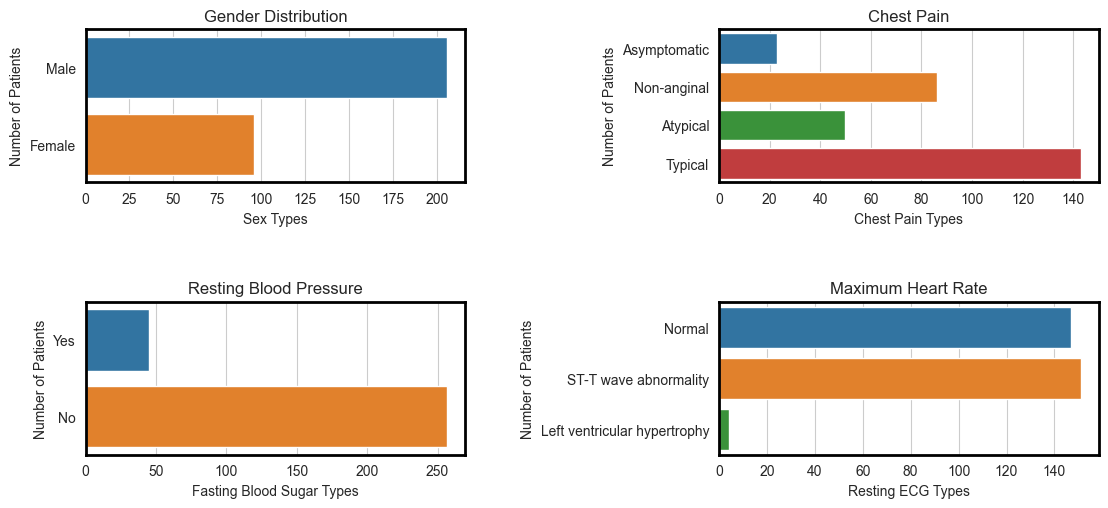

In [23]:
plot_meta = {
    'sex': {'title': 'Gender Distribution', 'xlabel': 'Sex Types','ylabel' : 'Number of Patients','hue' : 'sex'},
    'cp': {'title': 'Chest Pain', 'xlabel': 'Chest Pain Types','ylabel' : 'Number of Patients','hue' : 'cp'},
    'fbs': {'title': 'Resting Blood Pressure', 'xlabel':'Fasting Blood Sugar Types','ylabel' : 'Number of Patients','hue' : 'fbs'},
    'restecg': {'title': 'Maximum Heart Rate', 'xlabel': 'Resting ECG Types','ylabel' : 'Number of Patients','hue' : 'restecg'}
}

plt.figure(figsize=(12, 6))

for i, (col, meta) in enumerate(plot_meta.items()):
    ax=plt.subplot(2, 2, i+1)
    sns.countplot(data = temp_df,y= temp_df[col], fill=True,hue = temp_df[col])
    
    # --- BORDER LOGIC START ---
    for spine in ax.spines.values():
        spine.set_visible(True)      # Make sure the border is turned on
        spine.set_linewidth(2)     # Adjust thickness
        spine.set_edgecolor('black') # Change color (e.g., 'gray' or 'black')
    # --- BORDER LOGIC END ---
    
    plt.title(meta['title'])
    plt.xlabel(meta['xlabel'])
    plt.ylabel(meta['ylabel'])
    

plt.tight_layout(pad = 4)

### Checking the correlation with the target column

In [24]:
df.corr()['target']

age           -0.221476
sex           -0.283609
cp             0.432080
trestbps      -0.146269
chol          -0.095951
fbs           -0.026826
restecg        0.134874
thalach        0.419955
exang         -0.435601
oldpeak       -0.429146
slope          0.343940
ca            -0.408992
thal          -0.343101
target         1.000000
oldpeak_log   -0.430235
Name: target, dtype: float64

### Plotting violin plot of target vs numerical columns(thalach and oldpeak_log)

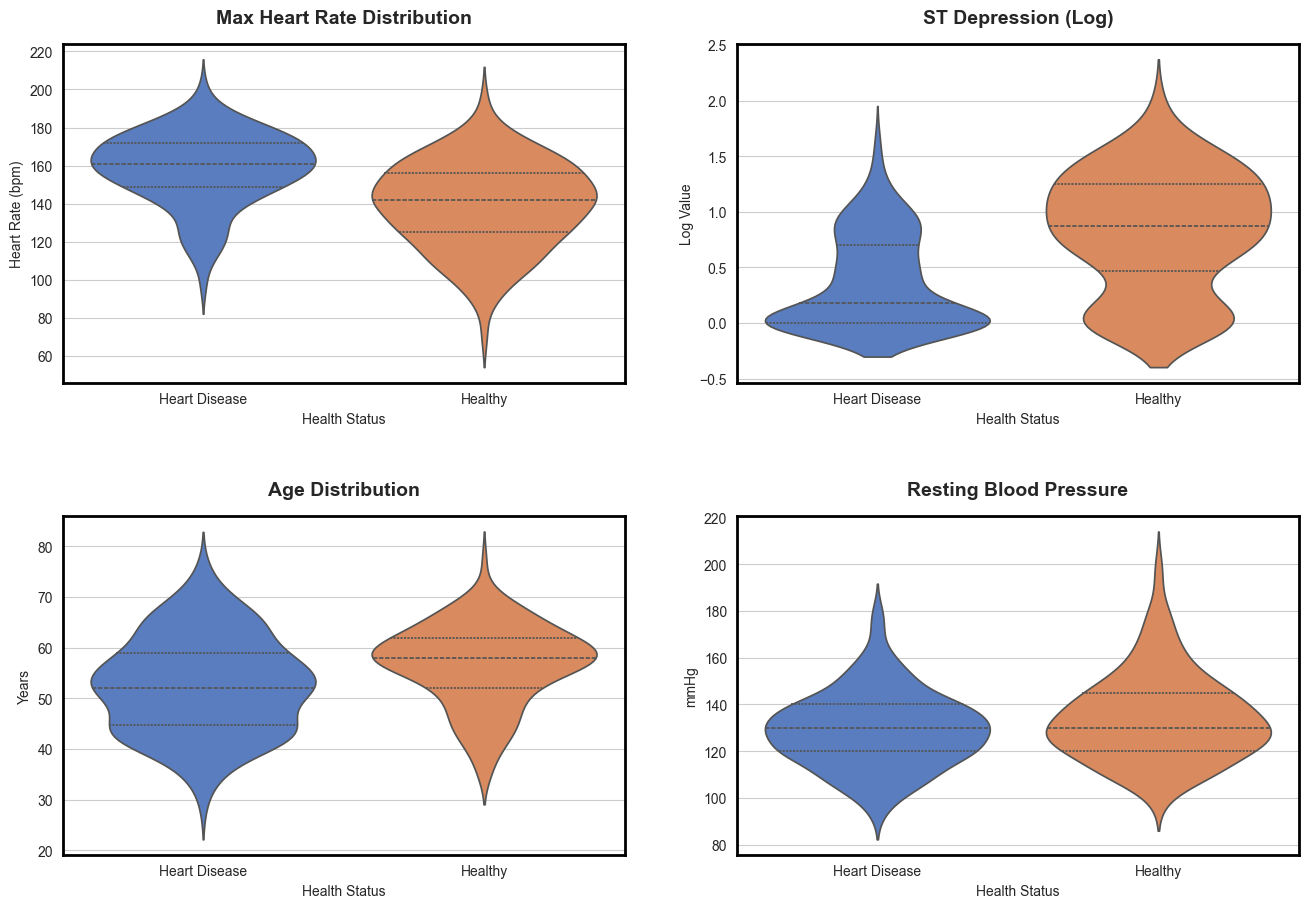

In [25]:
# 1. Map the target to strings so the x-axis is easy to read
temp_df['target_label'] = temp_df['target'].map({0: 'Healthy', 1: 'Heart Disease'})

# 2. Update metadata for Continuous Variables
# We'll use the ones you were curious about in the scatter plots
violin_meta = {
    'thalach': {'title': 'Max Heart Rate Distribution', 'xlabel': 'Health Status', 'ylabel': 'Heart Rate (bpm)'},
    'oldpeak_log': {'title': 'ST Depression (Log)', 'xlabel': 'Health Status', 'ylabel': 'Log Value'},
    'age': {'title': 'Age Distribution', 'xlabel': 'Health Status', 'ylabel': 'Years'},
    'trestbps': {'title': 'Resting Blood Pressure', 'xlabel': 'Health Status', 'ylabel': 'mmHg'}
}

plt.figure(figsize=(14, 10))

for i, (col, meta) in enumerate(violin_meta.items()):
    ax = plt.subplot(2, 2, i+1)
    
    # x is our category (Healthy/Sick), y is our numeric value
    sns.violinplot(data=temp_df, x='target_label', y=col, palette='muted',hue = temp_df['target_label'], inner='quartile')
    
    # --- BORDER LOGIC ---
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor('black')
    
    plt.title(meta['title'], fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(meta['xlabel'])
    plt.ylabel(meta['ylabel'])

plt.tight_layout(pad=4.0)
plt.show()

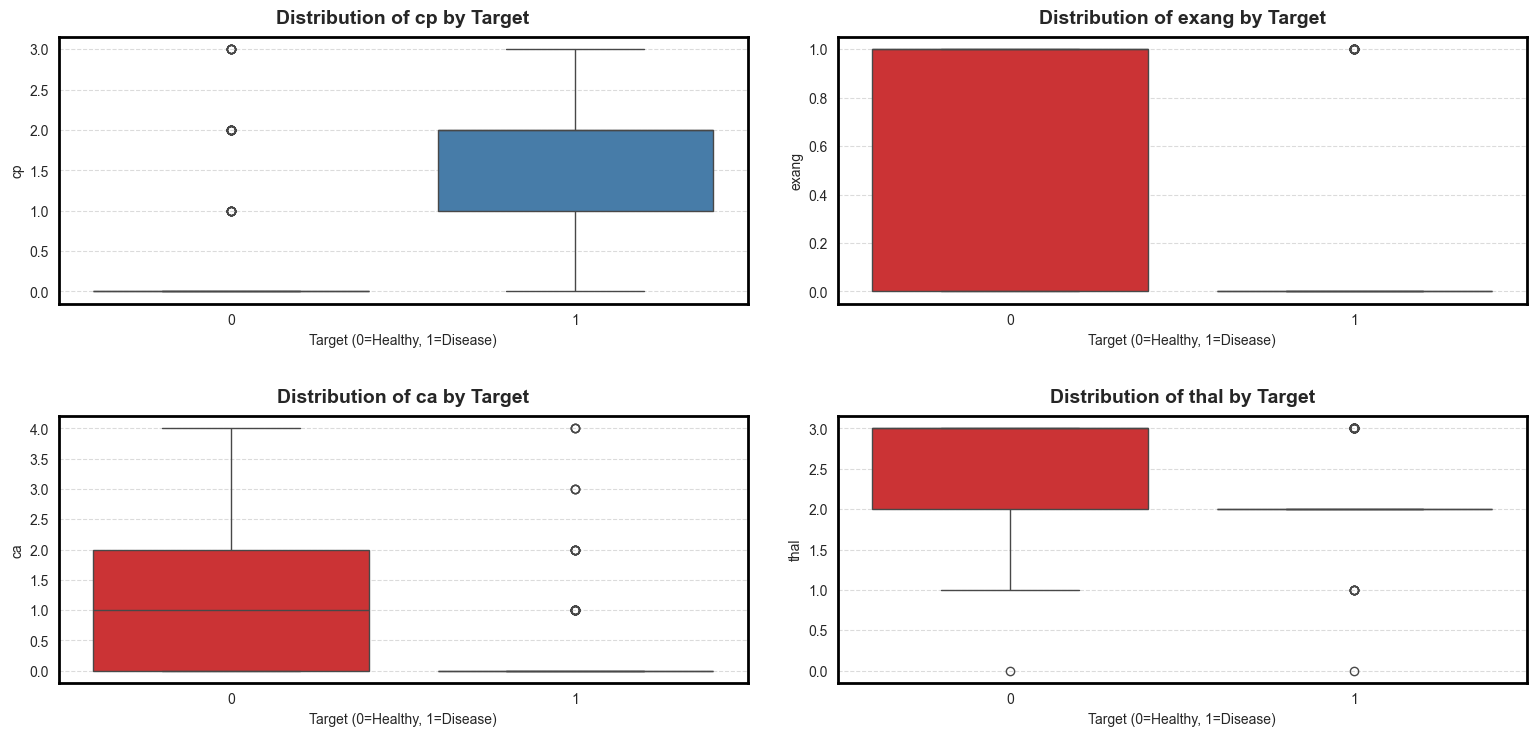

In [49]:
cols = ['cp', 'exang', 'ca', 'thal']

# 1. Increase figsize for the 2x2 grid
plt.figure(figsize=(16, 8))

for i, col in enumerate(cols):
    # 2. Define the subplot (2 rows, 2 columns)
    ax = plt.subplot(2, 2, i+1)
    
    # 3. Create the boxplot
    sns.boxplot(x='target', y=col, data=df, palette='Set1', hue='target', legend=False)

    # --- BORDER LOGIC ---
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor('black')
    
    # 4. Styling and Labels
    plt.title(f"Distribution of {col} by Target", fontsize=14, fontweight='bold', pad=10)
    plt.xlabel("Target (0=Healthy, 1=Disease)")
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Prevent overlapping and show at the end
plt.tight_layout(pad=3.0)


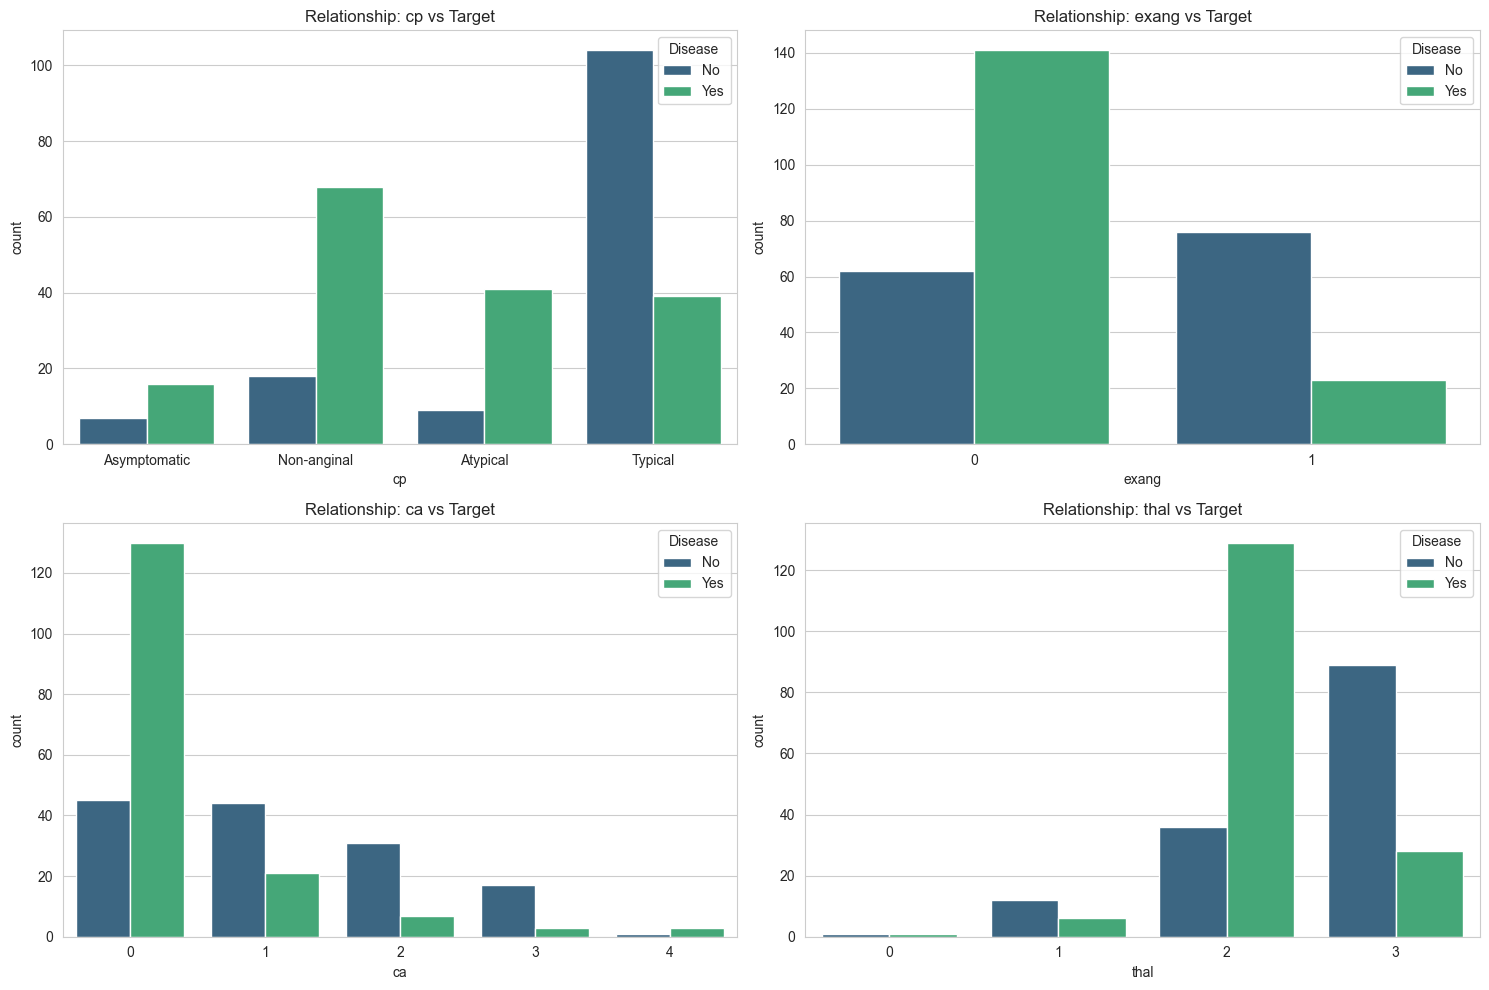

In [27]:
# The attributes you mentioned
cat_cols = ['cp', 'exang', 'ca', 'thal']

plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)
    
    # Using hue='target' is the key here!
    sns.countplot(data=temp_df, x=col, hue='target', palette='viridis')
    
    plt.title(f'Relationship: {col} vs Target')
    plt.legend(title='Disease', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

## Drawing the heatMap

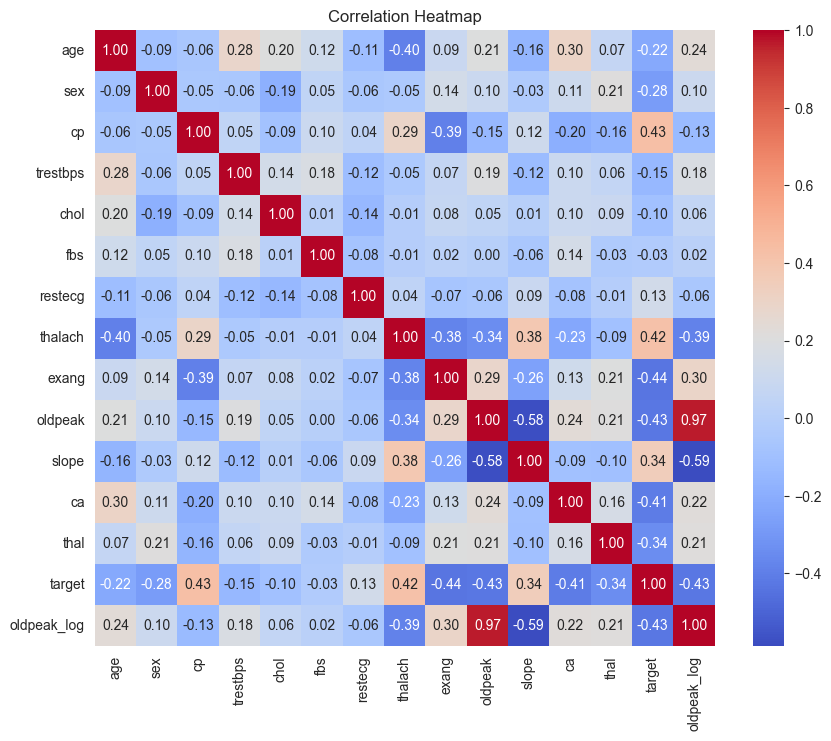

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    
)

plt.title("Correlation Heatmap")
plt.show()

In [29]:
## As oldpeak and oldpeak_log has high orrelation, so to avoid multicollenearity, we have droppes the original oldpeak
df.drop('oldpeak', axis=1, inplace=True)

print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'slope', 'ca', 'thal', 'target', 'oldpeak_log'],
      dtype='object')


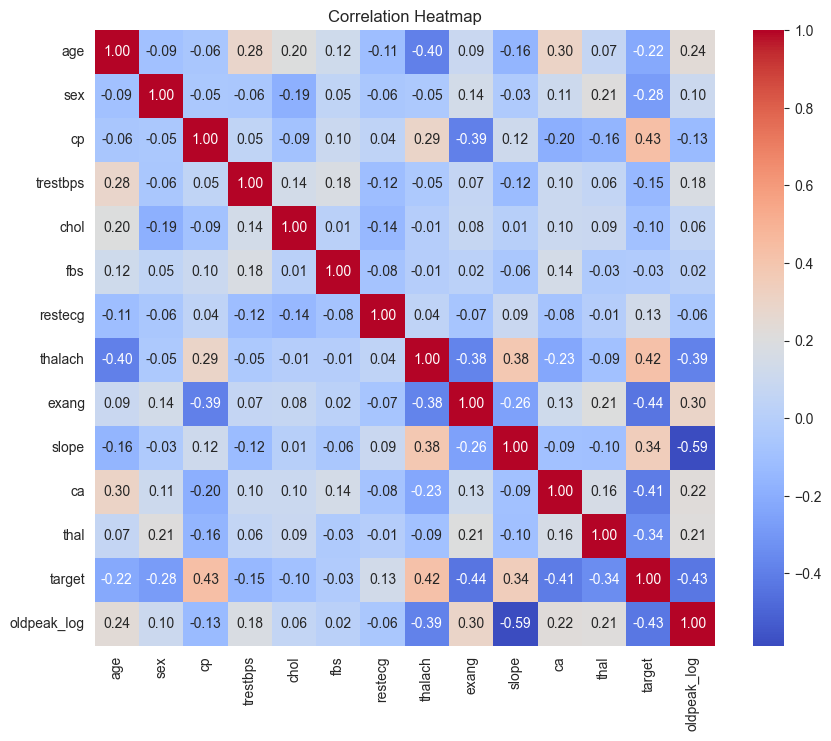

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    
)

plt.title("Correlation Heatmap")
plt.show()

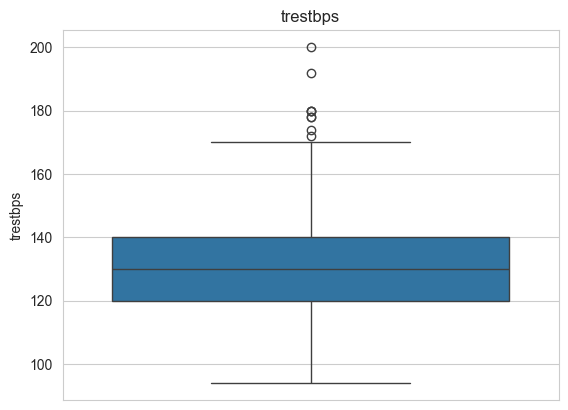

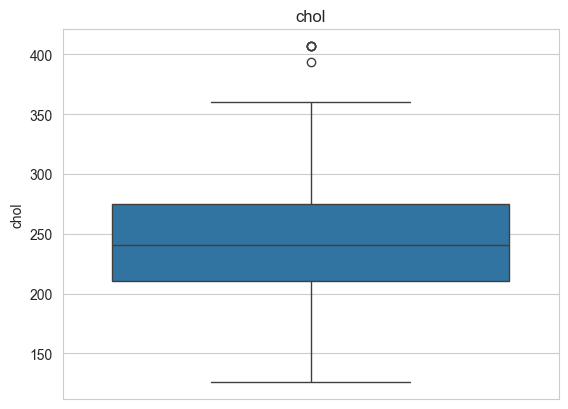

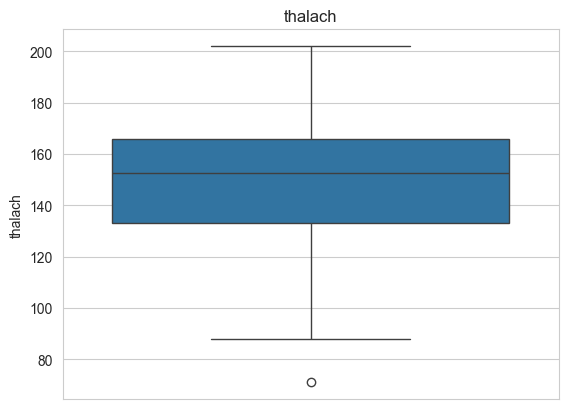

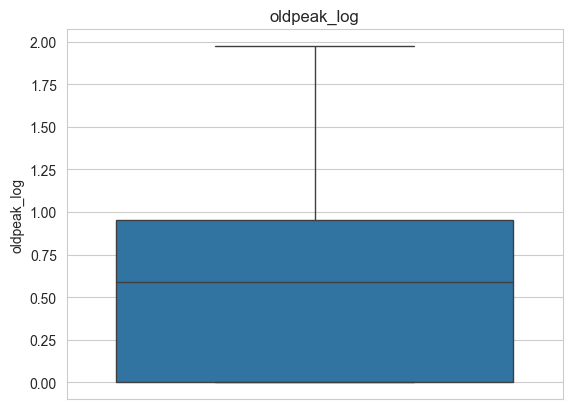

In [31]:
cols = ['trestbps','chol','thalach','oldpeak_log']
for col in cols:
        plt.figure()
        sns.boxplot(y=df[col])
        plt.title(col)
        plt.show()

# Handling the outliers with Z-Score

In [32]:
# 1. Define the columns where you want to check for outliers
columns_to_check = ['trestbps', 'chol', 'thalach', 'oldpeak_log']

# 2. Calculate Z-scores for these columns
z_scores = np.abs(stats.zscore(df[columns_to_check]))

# 3. Define a threshold (standard is 3)
threshold = 3

# 4. Identify indices of outliers
outlier_indices = np.where(z_scores > threshold)

# Capping them 
# This keeps the data but brings the outliers closer to the mean
for col in columns_to_check:
    col_zscore = stats.zscore(df[col])
    upper_limit = df[col].mean() + 3 * df[col].std()
    lower_limit = df[col].mean() - 3 * df[col].std()
    df[col] = np.where(df[col] > upper_limit, upper_limit, 
                       np.where(df[col] < lower_limit, lower_limit, df[col]))

print(f"Original shape: {df.shape}")

Original shape: (302, 14)


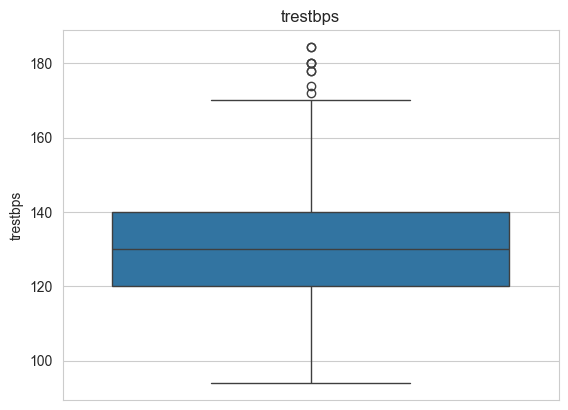

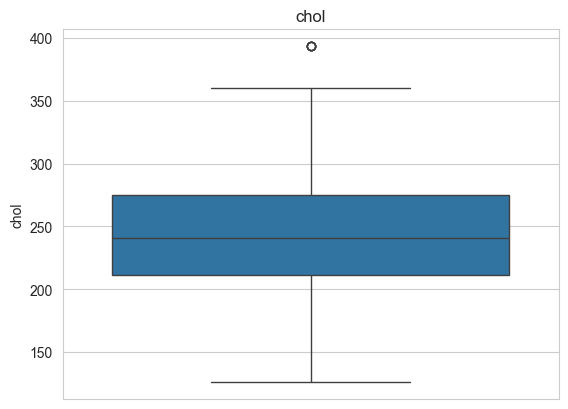

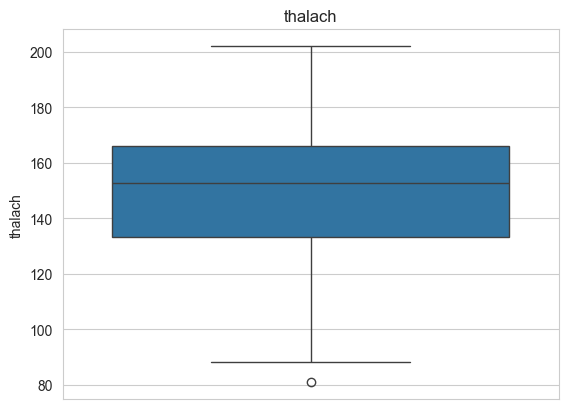

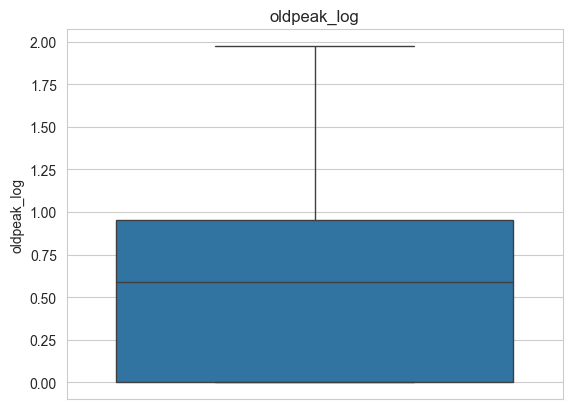

In [33]:
cols = ['trestbps','chol','thalach','oldpeak_log']
for col in cols:
        plt.figure()
        sns.boxplot(y=df[col])
        plt.title(col)
        plt.show()

# Training the Model 

In [34]:
X = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'ca', 'thal'], drop_first=True)
y = df['target']

In [35]:
X = df.drop('target', axis=1)
y = df['target']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# Scaling (Essential for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
#Calculate Metrics on TEST DATA
y_pred = model.predict(X_test_scaled)
# Creating the Risk Percentage
risk_probabilities = model.predict_proba(X_test_scaled)[:, 1] * 100


In [40]:
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Risk Separation (AUC): {roc_auc_score(y_test, risk_probabilities):.2f}")

Test Accuracy: 0.82
Risk Separation (AUC): 0.93


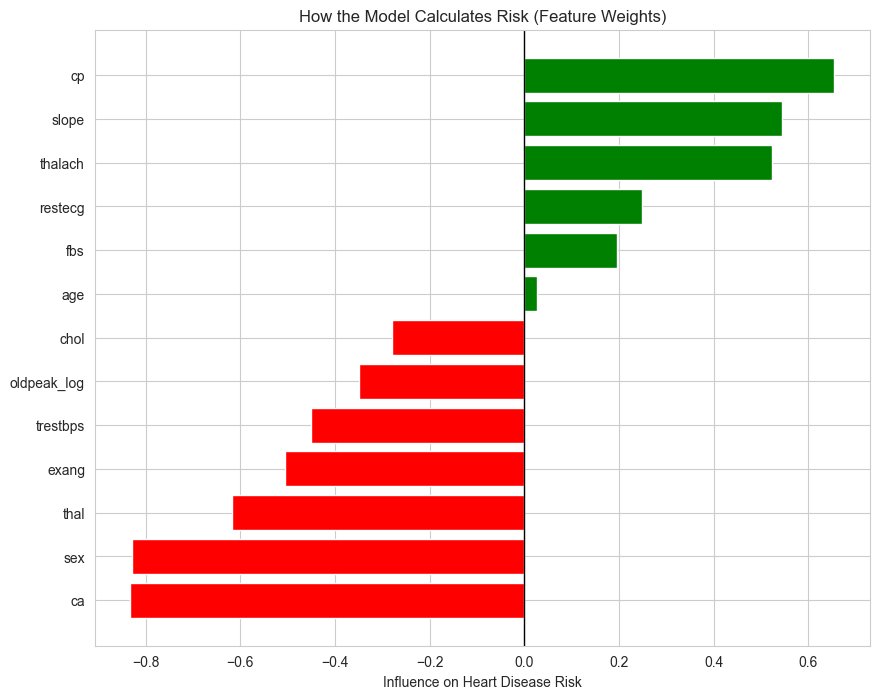

In [41]:
# Extract weights from the model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0]
}).sort_values(by='Weight', ascending=True)

# Plotting
plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in feature_importance['Weight']]
plt.barh(feature_importance['Feature'], feature_importance['Weight'], color=colors)
plt.axvline(0, color='black', lw=1)
plt.title('How the Model Calculates Risk (Feature Weights)')
plt.xlabel('Influence on Heart Disease Risk')
plt.show()

In [42]:
def final_heart_risk_assessment(patient_raw_data, threshold=30):
    """
    1. Preprocesses a single patient's data.
    2. Calculates the risk percentage.
    3. Applies a custom safety threshold.
    4. Explains the top 3 drivers for this specific patient.
    """
    
    # --- Step 1: Preprocessing ---
    # Convert input to DataFrame (Ensure columns match X.columns exactly)
    patient_df = pd.DataFrame([patient_raw_data])
    
    # Apply the same logic used in training: Capping and Log Transformation
    # (Example: Capping cholesterol at 406.7)
    if 'chol' in patient_df.columns:
        patient_df['chol'] = np.where(patient_df['chol'] > 406.7, 406.7, patient_df['chol'])
    
    # --- Step 2: Scaling ---
    patient_scaled = scaler.transform(patient_df)
    
    # --- Step 3: Risk Calculation ---
    risk_percentage = model.predict_proba(patient_scaled)[:, 1][0] * 100
    
    # --- Step 4: Threshold Alert ---
    if risk_percentage >= threshold:
        status = "⚠️ HIGH RISK / ACTION REQUIRED"
        recommendation = "Consult a cardiologist immediately for diagnostic verification."
    else:
        status = "✅ LOW TO MODERATE RISK"
        recommendation = "Standard lifestyle monitoring and annual check-up."

    # --- Step 5: Local Explainability (Why?) ---
    weights = model.coef_[0]
    contributions = patient_scaled[0] * weights
    
    explanation_df = pd.DataFrame({
        'Feature': X.columns,
        'Contribution': contributions
    }).sort_values(by='Contribution', ascending=False)
    
    top_drivers = explanation_df.head(3)['Feature'].tolist()

    # --- Final Output ---
    print(f"--- HEART DISEASE RISK REPORT ---")
    print(f"Final Risk Score: {risk_percentage:.2f}%")
    print(f"Status: {status}")
    print(f"Top 3 Risk Factors for this Patient: {', '.join(top_drivers)}")
    print(f"Medical Recommendation: {recommendation}")
    print(f"---------------------------------")
    
    return explanation_df

## Testing on first 5 lines of testing data

In [44]:
# Testing the function on the first 5 rows of your test set
print("--- TESTING BATCH ---")
for i in range(5):
    # We take a raw row from X_test (before it was scaled)
    sample_patient = X_test.iloc[i] 
    final_heart_risk_assessment(sample_patient)
    print("\n")

--- TESTING BATCH ---
--- HEART DISEASE RISK REPORT ---
Final Risk Score: 1.43%
Status: ✅ LOW TO MODERATE RISK
Top 3 Risk Factors for this Patient: restecg, age, trestbps
Medical Recommendation: Standard lifestyle monitoring and annual check-up.
---------------------------------


--- HEART DISEASE RISK REPORT ---
Final Risk Score: 13.60%
Status: ✅ LOW TO MODERATE RISK
Top 3 Risk Factors for this Patient: cp, ca, restecg
Medical Recommendation: Standard lifestyle monitoring and annual check-up.
---------------------------------


--- HEART DISEASE RISK REPORT ---
Final Risk Score: 86.10%
Status: ⚠️ HIGH RISK / ACTION REQUIRED
Top 3 Risk Factors for this Patient: chol, cp, thalach
Medical Recommendation: Consult a cardiologist immediately for diagnostic verification.
---------------------------------


--- HEART DISEASE RISK REPORT ---
Final Risk Score: 4.63%
Status: ✅ LOW TO MODERATE RISK
Top 3 Risk Factors for this Patient: thal, oldpeak_log, restecg
Medical Recommendation: Standard l

In [45]:
import joblib
# Save the "Brain"
joblib.dump(model, 'heart_disease_model.pkl')
# Save the "Ruler" (so the app knows how to scale new data)
joblib.dump(scaler, 'heart_scaler.pkl')
# Save the list of columns (important for the dummy variables!)
# Convert the Pandas Index to a simple list of strings
joblib.dump(list(X.columns), 'model_columns.pkl')

['model_columns.pkl']